# What is the minimum intensity difference required between adjacent pixels for a human to perceive a difference? What should the intensity difference between adjacent pixels be to ensure the minimum contrast threshold?

Source of inspiration: [Lecture №2](https://drive.google.com/file/d/1zjxITlrtviEWQQ0-IxMBQM7h48bFYW2f/view)

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "numpy",
    "matplotlib",
    "opencv-python",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


## Contrast

Source: [PhD dissertation: f. (3.1), p. 103](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)

Object-to-background contrast:
$$
 C_{ob}=\frac{\Phi _{ob} - \Phi _{bg}}{\Phi _{ob} + \Phi _{bg}}=
\frac{\Delta \Phi }{2 \Phi _{bg} + \Delta \Phi }
$$
where:
$\Phi _{ob}$ – radiant flux from the object in $W$, $\Phi _{bg}$ – radiant flux from the background in $W$, $\Delta \Phi$ – flux difference in $W$.

Source: [PhD dissertation: f. (4.73), p. 170](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)

The integral radiant flux incident on the eye (or on the sensor):
$$
\Phi \approx \mu  \cdot \frac{M_{T} A_{1} A_{2}}{\pi L_{ab}^{2}}
$$
where:
$\mu$ – emissivity of a gray body, $A_{1}$ – emitting area of the screen in $cm^{2}$, $A_{2}$ – active area of the detector or image area in the focal plane (of the eye) in $cm^{2}$, $L_{ab}$ – source-to-detector distance in $cm$, $M_{T}$ – the integral radiant emittance of an object at a given temperature T.

Source: [PhD dissertation: f. (4.72), p. 170](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)

The solid angle within which radiation from the object enters the entrance pupil:
$$
 \Omega = \frac{A_{1}}{L_{ab}^{2}} = \frac{A_{2}}{f_{eye}^{2}}
$$
where:
$f_{eye}$ – the focal length of the eye.

Source: [Focal Length of a Human Eye](https://hypertextbook.com/facts/2002/JuliaKhutoretskaya.shtml)
$$
f_{eye} = 1.7 cm
$$

We have:
$$
 A_{2}=\frac{A_{1}\cdot f_{eye}^{2}}{L_{ab}^2}
$$

Making a substitution in the formula, we get:
$$
\Phi = \mu \cdot A_{1}^{2} \cdot \frac{M_{T} }{ \pi } \left ( \frac{f_{eye}}{L_{ab}^2} \right ) ^{2}
$$

Then we have:
$$
\Delta \Phi = \Phi _{ob} - \Phi _{bg} = \left ( \mu_{ob} \cdot A_{1,ob}^{2} - \mu_{bg} \cdot A_{1,bg}^{2} \right ) \cdot \frac{M_{T} }{ \pi } \left ( \frac{f_{eye}}{L_{ab}^2} \right ) ^{2}
$$

We can also write that:
$$
\mu _{ob} = \mu _{bg} + \Delta \mu
$$

We can rewrite the contrast equation as:
$$
 C_{ob}= \frac{ \left ( \mu_{ob} \cdot A_{1,ob}^{2} - \mu_{bg} \cdot A_{1,bg}^{2} \right ) \cdot \frac{M_{T} }{ \pi } \left ( \frac{f_{eye}}{L_{ab}^2} \right ) ^{2} } { \left (2 \mu_{bg} \cdot A_{1,bg}^{2} + \mu_{ob} \cdot A_{1,ob}^{2} - \mu_{bg} \cdot A_{1,bg}^{2} \right ) \cdot \frac{M_{T} }{ \pi } \left ( \frac{f_{eye}}{L_{ab}^2} \right ) ^{2} } =
 \frac{ \mu_{ob} \cdot A_{1,ob}^{2} - \mu_{bg} \cdot A_{1,bg}^{2} } {\mu_{ob} \cdot A_{1,ob}^{2} + \mu_{bg} \cdot A_{1,bg}^{2} }
$$
$$
 C_{ob} = 1 - \frac{2 \mu_{bg} A_{1,bg}^{2}}{\Delta \mu \cdot A_{ob}^2 + \mu_{bg} \left ( A_{ob}^2 + A_{bg}^{2} \right )}
$$

We can express $\Delta \mu$ from the equation as:
$$
\Delta \mu = \mu_{bg} \cdot \left [ \left ( \frac{A_{bg}}{A_{ob}} \right )^{2} \cdot \left ( \frac{1 + C_{ob}}{1 - C_{ob}} \right ) - 1 \right ]
$$

Under the condition that $A_{ob} = A_{bg}$, we obtain:
$$
\Delta \mu = \mu_{bg} \cdot \left ( \frac{ 2 \cdot C_{ob}}{1 - C_{ob}} \right )
$$

Source: [Eye intensity response, contrast sensitivity](https://www.telescope-optics.net/eye_intensity_response.htm)

 Contrast threshold of the eye:
$$
C_{th,eye} = 1.5\%
$$

In [42]:
import numpy as np


def calc_delta_mu_by_contrast(mu: np.ndarray | float,
                              c_th: np.ndarray | float,
                              a_bg: np.ndarray | float = 1.0,
                              a_ob: np.ndarray | float = 1.0) -> np.ndarray | float:
    """
    Calculate the intensity difference between adjacent pixels
    :param mu: intensity of the background
    :param c_th: contrast threshold
    :param a_bg: area of the background
    :param a_ob: area of the object
    :return: intensity difference
    """
    return mu * ((a_bg / a_ob) ** 2) * ((1 + c_th) / (1 - c_th) - 1)



In [43]:
import numpy as np

A_ob = 1
A_bg = 1 * A_ob
C_th = 1.5 / 100
max_bit = 255
mu_min = 0
mu_max = 255
n_points = 256

mu_bg = np.linspace(mu_min, mu_max, n_points)

delta_mu = calc_delta_mu_by_contrast(mu_bg, C_th, A_bg, A_ob)


Attribute,Result
"Intensity of the background, $\mu_{bg}$",100
"Intensity difference between adjacent pixels, $\Delta \mu$",4
"Intensity of the object, $\mu_{bg}$",104


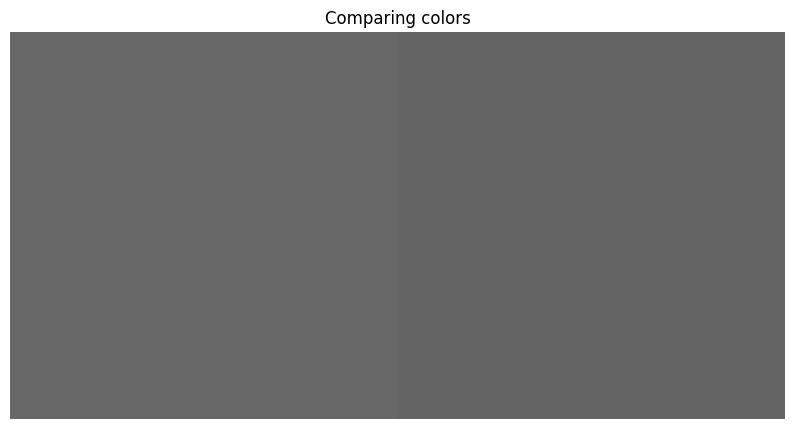

In [66]:
import numpy as np
import apps.reporter as rpt
import matplotlib.pyplot as plt

img_height = 100
img_width_ob = 100 * A_ob
img_width_bg = 100 * A_bg

mu_bg_test = 100
delta_mu_test = np.ceil(calc_delta_mu_by_contrast(mu_bg_test, C_th, A_bg, A_ob)).astype(np.uint8)
mu_ob_test = mu_bg_test + delta_mu_test

mu_bg_test = np.clip(mu_bg_test, mu_min, mu_max)
mu_ob_test = np.clip(mu_ob_test, mu_min, mu_max)

img_ob = np.full((img_height, img_width_ob, 3), mu_ob_test, dtype=np.uint8)
img_bg = np.full((img_height, img_width_bg, 3), mu_bg_test, dtype=np.uint8)
final_img = np.hstack([img_ob, img_bg])

rp = rpt.Reporter()
rp.add_item(f"Intensity of the background, $\\mu_{{bg}}$", str(mu_bg_test))
rp.add_item(f"Intensity difference between adjacent pixels, $\\Delta \\mu$", str(delta_mu_test))
rp.add_item(f"Intensity of the object, $\\mu_{{bg}}$", str(mu_ob_test))

rp.print_pd_report("Comparing colors")

_, ax = plt.subplots(figsize=(10, 6))

ax.imshow(final_img)
ax.axis(False)
plt.title("Comparing colors")
plt.show()

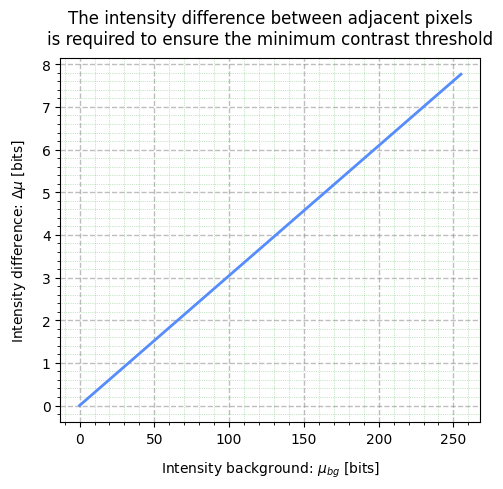

In [67]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(figsize=(5, 5))
ax = axes

ax.plot(mu_bg, delta_mu, linewidth=2.0)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(f"The intensity difference between adjacent pixels\nis required to ensure the minimum contrast threshold",
             pad=10, loc='center', color='black')
ax.set_xlabel(f"Intensity background: $\\mu_{{bg}}$ [bits]", labelpad=10, loc='center', color='black')
ax.set_ylabel(f"Intensity difference: $\\Delta \\mu$ [bits]", labelpad=10, loc='center', color='black')

plt.tight_layout()
plt.show()

## Conclusion

Using this physical and mathematical model, ...

Note: This model is not fully precise; to accelerate computations and demonstrate the core concept, certain parameters have been omitted or simplified.